Converged at epoch 2174

Final XOR outputs:
Input: [-1. -1.], Target: -1, Output: -0.9741, Predicted: -1
Input: [-1.  1.], Target: 1, Output: 0.9814, Predicted: 1
Input: [ 1. -1.], Target: 1, Output: 0.9814, Predicted: 1
Input: [1. 1.], Target: -1, Output: -0.9747, Predicted: -1

Final Weights and Biases:
W1 =
 [[-1.47208285  1.76587465]
 [-1.46758042  1.75488574]]
b1 =
 [[-1.27696338 -1.62854189]]
W2 =
 [[-2.62827716]
 [-2.60012716]]
b2 =
 [[-2.32176839]]


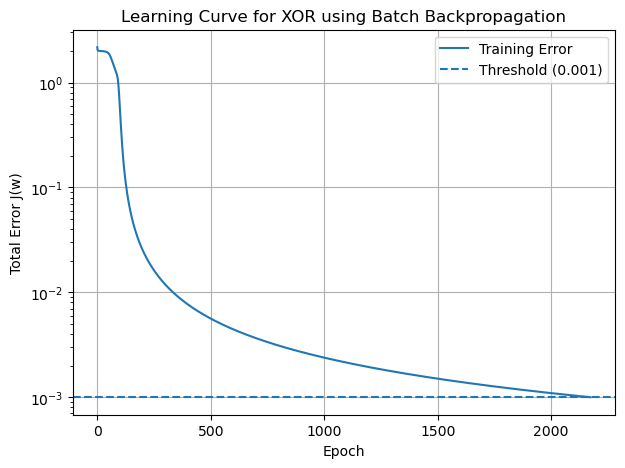

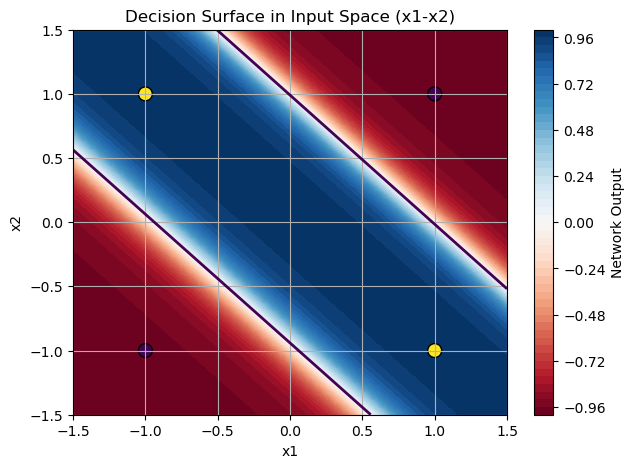

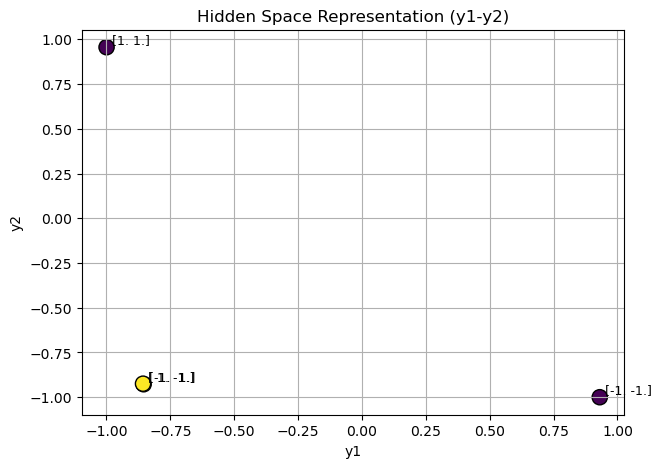

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# XOR Data
# -----------------------------
X = np.array([
    [-1, -1],
    [-1,  1],
    [ 1, -1],
    [ 1,  1]
], dtype=float)

T = np.array([
    [-1],
    [ 1],
    [ 1],
    [-1]
], dtype=float)

# -----------------------------
# Parameters
# -----------------------------
eta = 0.1
theta = 0.001
max_epochs = 50000
np.random.seed(7)

# -----------------------------
# Activation function
# f(x) = tanh(x)
# f'(x) = 1 - tanh^2(x)
# -----------------------------
def f(x):
    return np.tanh(x)

def fprime_from_output(y):
    return 1 - y**2

# -----------------------------
# Initialize weights and biases
# 2 inputs -> 2 hidden -> 1 output
# -----------------------------
W1 = np.random.uniform(-0.5, 0.5, (2, 2))   # hidden weights
b1 = np.random.uniform(-0.5, 0.5, (1, 2))   # hidden biases

W2 = np.random.uniform(-0.5, 0.5, (2, 1))   # output weights
b2 = np.random.uniform(-0.5, 0.5, (1, 1))   # output bias

errors = []

# -----------------------------
# Training: Batch Backpropagation
# -----------------------------
for epoch in range(max_epochs):
    dW1 = np.zeros_like(W1)
    db1 = np.zeros_like(b1)
    dW2 = np.zeros_like(W2)
    db2 = np.zeros_like(b2)

    total_error = 0.0

    for m in range(len(X)):
        x = X[m:m+1]   # shape (1,2)
        t = T[m:m+1]   # shape (1,1)

        # Forward pass
        net_h = x @ W1 + b1
        y_h = f(net_h)

        net_o = y_h @ W2 + b2
        y_o = f(net_o)

        # Error
        e = t - y_o
        total_error += 0.5 * np.sum(e**2)

        # Backprop
        delta_o = fprime_from_output(y_o) * (t - y_o)          # shape (1,1)
        delta_h = fprime_from_output(y_h) * (delta_o @ W2.T)   # shape (1,2)

        # Batch accumulate
        dW2 += eta * (y_h.T @ delta_o)
        db2 += eta * delta_o

        dW1 += eta * (x.T @ delta_h)
        db1 += eta * delta_h

    # Update after all samples
    W2 += dW2
    b2 += db2
    W1 += dW1
    b1 += db1

    errors.append(total_error)

    if total_error < theta:
        print(f"Converged at epoch {epoch + 1}")
        break

# -----------------------------
# Final results on XOR inputs
# -----------------------------
print("\nFinal XOR outputs:")
for i in range(len(X)):
    x = X[i:i+1]
    net_h = x @ W1 + b1
    y_h = f(net_h)
    net_o = y_h @ W2 + b2
    y_o = f(net_o)

    predicted = 1 if y_o[0, 0] >= 0 else -1
    print(f"Input: {X[i]}, Target: {T[i,0]:.0f}, Output: {y_o[0,0]:.4f}, Predicted: {predicted}")

print("\nFinal Weights and Biases:")
print("W1 =\n", W1)
print("b1 =\n", b1)
print("W2 =\n", W2)
print("b2 =\n", b2)

# -----------------------------
# Plot 1: Learning Curve
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(errors, label="Training Error")
# threshold line
plt.yscale("log")
plt.axhline(y=0.001, linestyle='--', label="Threshold (0.001)")
plt.xlabel("Epoch")
plt.ylabel("Total Error J(w)")
plt.title("Learning Curve for XOR using Batch Backpropagation")

plt.legend()
plt.grid(True)

plt.show()

# -----------------------------
# Plot 2: Decision Surface in x1-x2 space
# -----------------------------
x1_vals = np.linspace(-1.5, 1.5, 200)
x2_vals = np.linspace(-1.5, 1.5, 200)
xx1, xx2 = np.meshgrid(x1_vals, x2_vals)

grid_points = np.c_[xx1.ravel(), xx2.ravel()]
hidden_grid = f(grid_points @ W1 + b1)
output_grid = f(hidden_grid @ W2 + b2)
Z = output_grid.reshape(xx1.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx1, xx2, Z, levels=50, cmap="RdBu")
plt.colorbar(label="Network Output")
plt.contour(xx1, xx2, Z, levels=[0], linewidths=2)
plt.scatter(X[:, 0], X[:, 1], c=T[:, 0], edgecolors='k', s=100)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision Surface in Input Space (x1-x2)")
plt.grid(True)
plt.show()

# -----------------------------
# Plot 3: Hidden Layer Space y1-y2
# -----------------------------
hidden_outputs = f(X @ W1 + b1)

plt.figure(figsize=(7, 5))
plt.scatter(hidden_outputs[:, 0], hidden_outputs[:, 1], c=T[:, 0], edgecolors='k', s=120)
for i in range(len(X)):
    plt.text(hidden_outputs[i, 0] + 0.02, hidden_outputs[i, 1] + 0.02,
             f"{X[i]}", fontsize=9)

plt.xlabel("y1")
plt.ylabel("y2")
plt.title("Hidden Space Representation (y1-y2)")
plt.grid(True)
plt.show()